# UK House Price Predictor
## Phase 3: ML Modelling

**Goal:** Train and compare three machine learning models:
1. **Linear Regression** — simple baseline
2. **Random Forest** — robust ensemble method
3. **XGBoost** — gradient boosting, state-of-the-art for tabular data

**Evaluation metrics:**
- **RMSE** (Root Mean Squared Error) — average error in £
- **MAE** (Mean Absolute Error) — mean absolute error in £
- **R²** — proportion of variance explained (1.0 = perfect)

## 1. Install & Import Libraries

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '-q'])
print('Libraries ready')

Libraries ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries imported successfully')

All libraries imported successfully


## 2. Load & Prepare Data

In [3]:
df = pd.read_csv('dataset_ml.csv')

print(f'Dataset loaded: {len(df):,} rows')
print(f'Columns: {list(df.columns)}')

Dataset loaded: 739,435 rows
Columns: ['month', 'quarter', 'season_num', 'boe_rate', 'cpi', 'is_new_build', 'is_freehold', 'county_median', 'town_median', 'type_F', 'type_S', 'type_T', 'price']


In [4]:
target   = 'price'
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

print(f'Features ({len(features)}): {features}')
print(f'\nPrice range:')
print(f'  Min:    £{y.min():,.0f}')
print(f'  Max:    £{y.max():,.0f}')
print(f'  Median: £{y.median():,.0f}')

Features (12): ['month', 'quarter', 'season_num', 'boe_rate', 'cpi', 'is_new_build', 'is_freehold', 'county_median', 'town_median', 'type_F', 'type_S', 'type_T']

Price range:
  Min:    £10,000
  Max:    £10,000,000
  Median: £295,000


In [6]:
# Train / test split — 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train):,} rows')
print(f'Test set:     {len(X_test):,} rows')

Training set: 591,548 rows
Test set:     147,887 rows


In [7]:
# Scaling for Linear Regression (not needed for tree-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete')

Scaling complete


## 3. Evaluation Function

In [8]:
def evaluate_model(name, y_true, y_pred):
    """Calculate and print performance metrics for a model."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f'\n{"="*45}')
    print(f'  {name}')
    print(f'{"="*45}')
    print(f'  RMSE: £{rmse:,.0f}')
    print(f'  MAE:  £{mae:,.0f}')
    print(f'  R²:   {r2:.4f}')

    return {'name': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []
print('Evaluation function ready')

Evaluation function ready


## 4. Model 1: Linear Regression (Baseline)

The simplest model — establishes a performance floor that all other models must beat.

In [9]:
print('Training Linear Regression...')

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

res_lr = evaluate_model('Linear Regression (Baseline)', y_test, y_pred_lr)
results.append(res_lr)

# Feature coefficients
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print('\nTop 5 most influential features:')
print(coef_df.head())

Training Linear Regression...

  Linear Regression (Baseline)
  RMSE: £250,237
  MAE:  £121,253
  R²:   0.3787

Top 5 most influential features:
          feature    coefficient
8     town_median  165644.232411
9          type_F -114993.384656
11         type_T  -91662.078106
10         type_S  -76487.769972
7   county_median   19636.855651


## 5. Model 2: Random Forest

An ensemble of decision trees — handles non-linear relationships well and is robust to outliers.

In [10]:
print('Training Random Forest...')
print('(may take 1-2 minutes on a large dataset)')

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)
results.append(res_rf)

Training Random Forest...
(may take 1-2 minutes on a large dataset)

  Random Forest
  RMSE: £230,841
  MAE:  £106,690
  R²:   0.4713


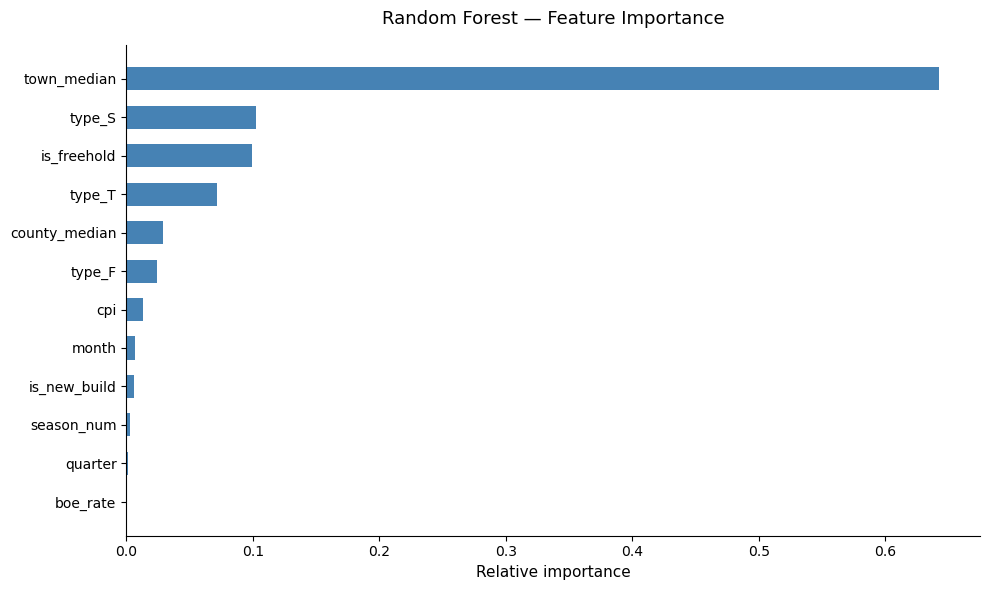

In [12]:
# Random Forest feature importance
fi_rf = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_rf['feature'], fi_rf['importance'], color='steelblue', height=0.6)
ax.set_title('Random Forest — Feature Importance', fontsize=13, pad=15)
ax.set_xlabel('Relative importance', fontsize=11)
plt.tight_layout()
plt.savefig('chart8_rf_feature_importance.png', dpi=150)
plt.show()

## 6. Model 3: XGBoost

Gradient boosting — the most powerful model for tabular data. Widely used in industry by companies like Zillow and Rightmove.

In [13]:
print('Training XGBoost...')
print('(may take 1-2 minutes)')

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)
results.append(res_xgb)

Training XGBoost...
(may take 1-2 minutes)

  XGBoost
  RMSE: £232,541
  MAE:  £107,954
  R²:   0.4634


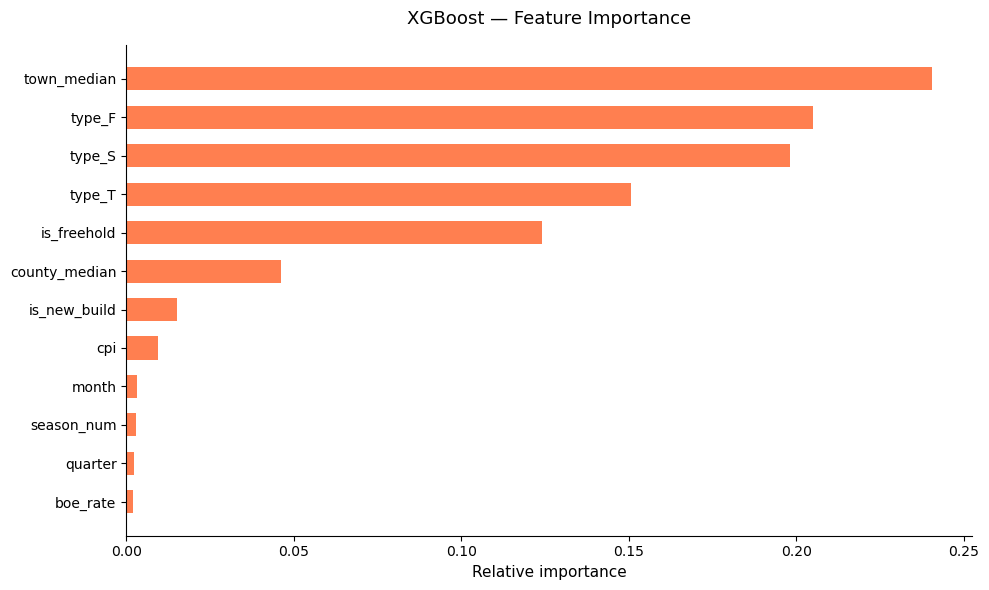

In [14]:
# XGBoost feature importance
fi_xgb = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_xgb['feature'], fi_xgb['importance'], color='coral', height=0.6)
ax.set_title('XGBoost — Feature Importance', fontsize=13, pad=15)
ax.set_xlabel('Relative importance', fontsize=11)
plt.tight_layout()
plt.savefig('chart9_xgb_feature_importance.png', dpi=150)
plt.show()

## 7. Model Comparison

In [15]:
df_results = pd.DataFrame(results)
df_results['RMSE'] = df_results['RMSE'].apply(lambda x: f'£{x:,.0f}')
df_results['MAE']  = df_results['MAE'].apply(lambda x: f'£{x:,.0f}')
df_results['R2']   = df_results['R2'].apply(lambda x: f'{x:.4f}')
df_results = df_results.rename(columns={'name': 'Model'}).set_index('Model')

print('\n=== FINAL COMPARISON ===')
print(df_results.to_string())


=== FINAL COMPARISON ===
                                  RMSE       MAE      R2
Model                                                   
Linear Regression (Baseline)  £250,237  £121,253  0.3787
Random Forest                 £230,841  £106,690  0.4713
XGBoost                       £232,541  £107,954  0.4634


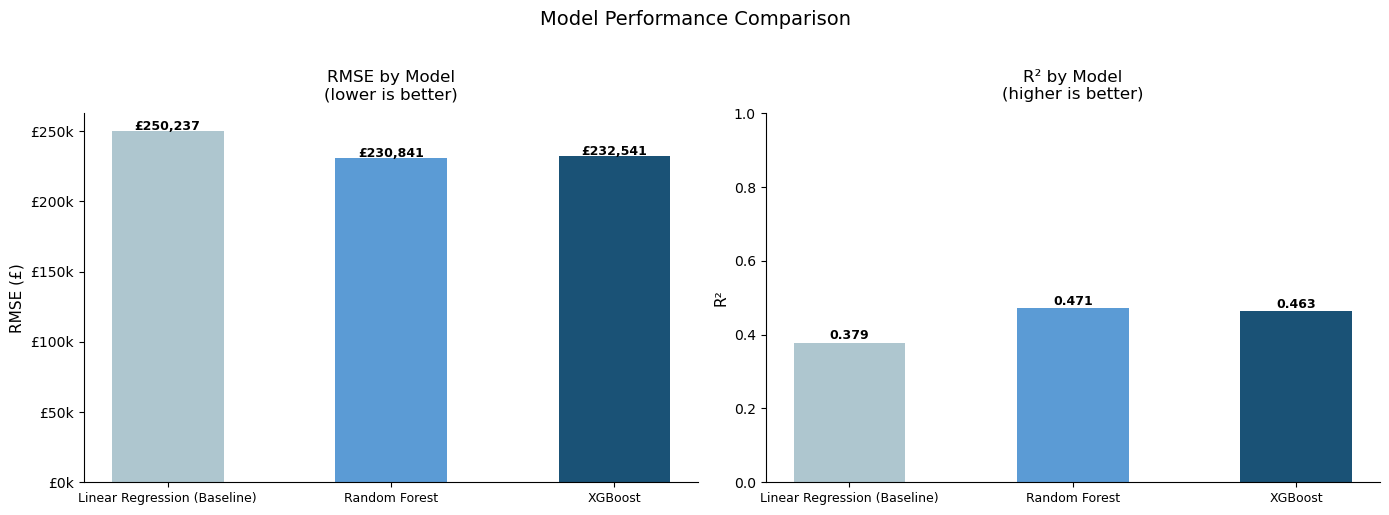

In [16]:
names  = [r['name'] for r in results]
rmse_v = [r['RMSE'] for r in results]
r2_v   = [r['R2']   for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colours = ['#aec6cf', '#5b9bd5', '#1a5276']

# RMSE
bars = ax1.bar(names, rmse_v, color=colours, width=0.5)
ax1.set_title('RMSE by Model\n(lower is better)', fontsize=12, pad=10)
ax1.set_ylabel('RMSE (£)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
for bar, val in zip(bars, rmse_v):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax1.tick_params(axis='x', labelsize=9)

# R²
bars2 = ax2.bar(names, r2_v, color=colours, width=0.5)
ax2.set_title('R² by Model\n(higher is better)', fontsize=12, pad=10)
ax2.set_ylabel('R²', fontsize=11)
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, r2_v):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.tick_params(axis='x', labelsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('chart10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

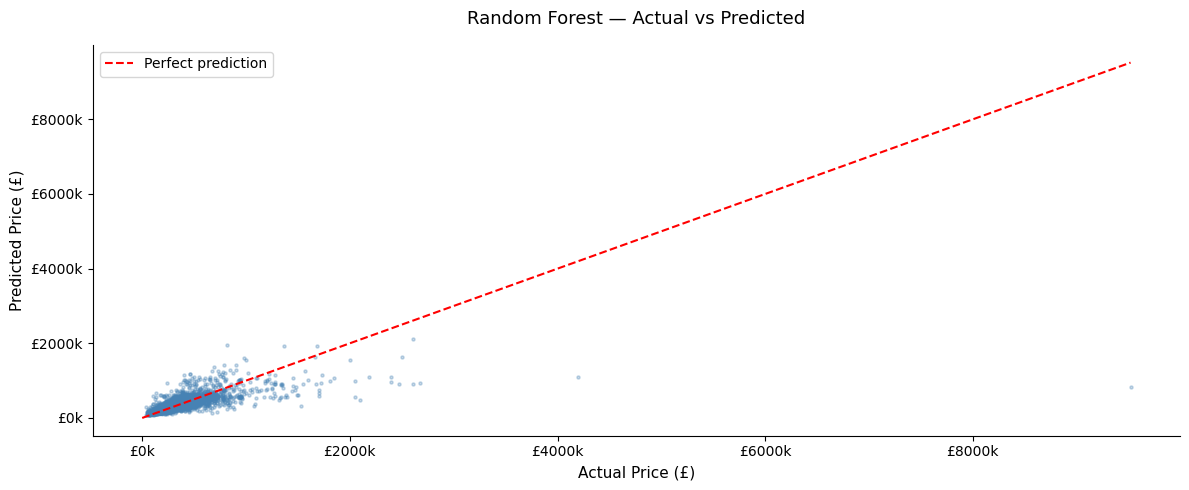

In [17]:
# Scatter: actual vs predicted (best model)
best_idx  = np.argmax([r['R2'] for r in results])
best_name = results[best_idx]['name']
best_pred = [y_pred_lr, y_pred_rf, y_pred_xgb][best_idx]

sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
y_test_arr = np.array(y_test)[sample_idx]
y_pred_arr = np.array(best_pred)[sample_idx]

fig, ax = plt.subplots()
ax.scatter(y_test_arr, y_pred_arr, alpha=0.3, s=5, color='steelblue')
lim = max(y_test_arr.max(), y_pred_arr.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title(f'{best_name} — Actual vs Predicted', fontsize=13, pad=15)
ax.set_xlabel('Actual Price (£)', fontsize=11)
ax.set_ylabel('Predicted Price (£)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('chart11_actual_vs_predicted.png', dpi=150)
plt.show()

## 8. Save the Best Model

In [18]:
import pickle

with open('model_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('features_list.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Model saved: model_xgboost.pkl')
print('Features saved: features_list.pkl')
print('\nReady for Phase 4: Streamlit Web App!')

Model saved: model_xgboost.pkl
Features saved: features_list.pkl

Ready for Phase 4: Streamlit Web App!


## Phase 3 Summary

- ✅ 80/20 train/test split
- ✅ Linear Regression baseline
- ✅ Random Forest with feature importance
- ✅ XGBoost with feature importance
- ✅ Visual comparison across all three models
- ✅ Actual vs predicted scatter plot
- ✅ Best model saved for deployment

**Next — Phase 4:** Build an interactive web app with Streamlit to make the project publicly accessible.